# Libraries

In [6]:
# Libraries
import numpy as np
import re
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
import networkx as nx
from adjustText import adjust_text

import gc
import re
import random
import math

import stringdb
import string
import logging

import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.colors import Normalize, LinearSegmentedColormap

import igraph as ig
import leidenalg

In [7]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/notebooks/Post-hoc_Analysis


# Load Networks

In [8]:
gc.collect()

# Biological priors with learning weights after supervised clustering
sc1_go = pd.read_excel("../../PASNet/Output/GO/sc1_weights.xlsx", index_col=0)
pt = pd.read_excel("../../PASNet/Input/GO/pt_fixed.xlsx", index_col=0)

sc1_go.columns = pt.columns
sc1_go.index = pt.index

### data pre-processing to obtain the actual sc1_weights
data = []
for pathway, series in sc1_go.iterrows():
    for gene, value in series.items():
        data.append([pathway, gene, value])

# PASNet outputs (source:pathway; target:protein; Weight:learning weights from PASNet)
df_go = pd.DataFrame(data, columns=['source', 'target', 'Weight'])
df_go = df_go[df_go['Weight'] != 0]

gc.collect()

# Biological priors with learning weights after supervised clustering
sc1_rest = pd.read_excel("../../PASNet/Output/REST/sc1_weights.xlsx", index_col=0)
pt = pd.read_excel("../../PASNet/Input/REST/pt_fixed.xlsx", index_col=0)

sc1_rest.columns = pt.columns
sc1_rest.index = pt.index

### data pre-processing to obtain the actual sc1_weights
data = []
for pathway, series in sc1_rest.iterrows():
    for gene, value in series.items():
        data.append([pathway, gene, value])

# PASNet outputs (source:pathway; target:protein; Weight:learning weights from PASNet)
df_rest = pd.DataFrame(data, columns=['source', 'target', 'Weight'])
df_rest = df_rest[df_rest['Weight'] != 0]

df = pd.concat([df_go, df_rest], ignore_index=True)
df['source'] = df['source'].str.replace(r' (\(GO|WP|R-HSA).*$', '', regex=True)

pasnet_genes = df['target'].unique()
len(pasnet_genes)

362

# Range of sc1 Weights

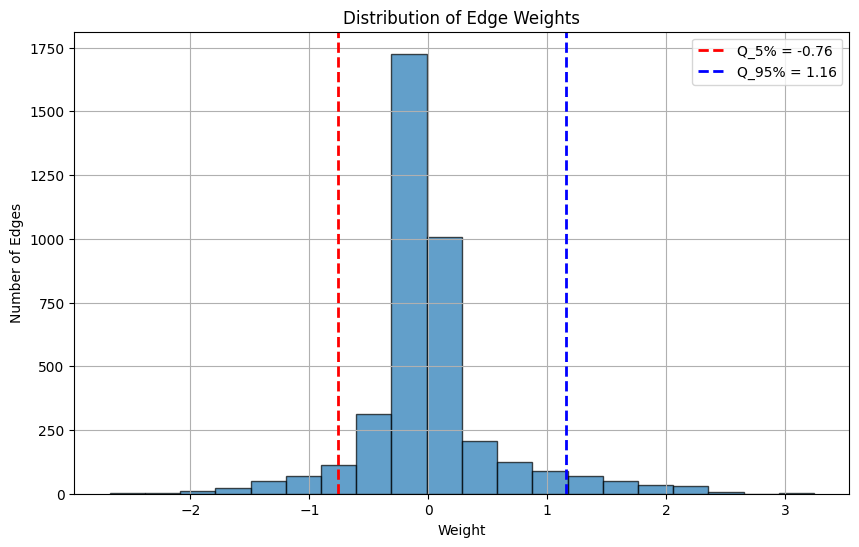

In [4]:
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df and has a 'Weight' column
weight_values = df['Weight']

# Calculate Q1 and Q3
q1 = weight_values.quantile(0.05)
q3 = weight_values.quantile(0.95)

plt.figure(figsize=(10, 6))
plt.hist(weight_values, bins=20, edgecolor='black', alpha=0.7)

# Add vertical lines for Q1 and Q3
plt.axvline(x=q1, color='red', linestyle='--', linewidth=2, label=f'Q_5% = {q1:.2f}')
plt.axvline(x=q3, color='blue', linestyle='--', linewidth=2, label=f'Q_95% = {q3:.2f}')

plt.title('Distribution of Edge Weights')
plt.xlabel('Weight')
plt.ylabel('Number of Edges')
plt.grid(True)
plt.legend()
plt.show()

In [5]:
df = df[(df['Weight'] > 1.16) | (df['Weight'] < -0.76)]

In [6]:
#Harmonizing with the SJARACNe file format that is to follow
genes_list = pd.concat([df['source'], df['target']]).unique().tolist()

df['MI'] = None
df['spearman'] = None
df['p-value'] = None

In [7]:
df_sj_sig = pd.read_csv("../../results/ICGC/SJARACNe_networks/output_sig_sjaracne_ICGC_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')
df_sj_tf = pd.read_csv("../../results/ICGC/SJARACNe_networks/output_tf_sjaracne_ICGC_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')
df_sj_nc = pd.read_csv("../../results/ICGC/SJARACNe_networks/output_nc_sjaracne_ICGC_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')

# Row binding the two dataframes
df_sj = pd.concat([df_sj_sig, df_sj_tf, df_sj_nc], axis=0, ignore_index=True)

# Removing duplicates based on columns "source" and "target"
df_sj = df_sj.drop_duplicates(subset=['source', 'target'])

# Keep only the specified columns: source, label, MI, spearman, p-value
columns_to_keep = ['source', 'target', 'MI', 'spearman', 'p-value']
df_sj = df_sj[columns_to_keep]

#Harmonizing with PASNet outputs
df_sj['Weight'] = None
df_sj = df_sj[df_sj['p-value'] <= 0.05]

df_sj['sorted_pair'] = df_sj.apply(lambda row: tuple(sorted([row['source'], row['target']])), axis=1)
df_sj = df_sj.sort_values(by='MI', ascending=False).drop_duplicates(subset=['sorted_pair']).drop(columns=['sorted_pair'])

combined_df_net = pd.concat([df, df_sj], ignore_index=True)
len(combined_df_net)

/tmp/ipykernel_1708/2525885695.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df_net = pd.concat([df, df_sj], ignore_index=True)


395228

# Load NetBID2 res

In [8]:
res_icgc = pd.read_excel("../../results/ICGC/ICGC_NetBID2_ms_tab.xlsx")
res_icgc = res_icgc[['originalID', 'funcType', 'Size', 'logFC.U.Vs.M_DA', 'adj.P.Val.U.Vs.M_DA', 'Z.U.Vs.M_DA', 'logFC.U.Vs.M_DE', 'adj.P.Val.U.Vs.M_DE', 'Z.U.Vs.M_DE']]
res_icgc.rename(columns={
    'originalID': 'ID',
    'funcType': 'Type',
    'logFC.U.Vs.M_DA': 'logFC_DA',
    'adj.P.Val.U.Vs.M_DA': 'adj.P.Val_DA',
    'Z.U.Vs.M_DA': 'Z-score_DA',
    'logFC.U.Vs.M_DE': 'logFC_DE',
    'adj.P.Val.U.Vs.M_DE': 'adj.P.Val_DE',
    'Z.U.Vs.M_DE': 'Z-score_DE',
}, inplace=True)

# Create a temporary column to give priority to "TF" rows
res_icgc['priority'] = res_icgc['Type'].apply(lambda x: 0 if x == 'TF' else 1)

# Sort the DataFrame by the 'priority' column (TF first) and by ID to make sure we keep the first occurrence
res_icgc = res_icgc.sort_values(by=['priority', 'ID'])

# Remove duplicated rows by 'ID', keeping the first occurrence (which should be the "TF" if it's present)
res_icgc = res_icgc.drop_duplicates(subset='ID', keep='first')

res_icgc = res_icgc.drop(columns=['priority'])

res_icgc_filt_overt = res_icgc[
    (res_icgc['adj.P.Val_DA'] < 0.05) &
    (res_icgc['adj.P.Val_DE'] < 0.05) &
    (res_icgc['Size'] > 30)
]

res_icgc_filt_hidden = res_icgc[
    (res_icgc['adj.P.Val_DA'] < 0.05) &
    (res_icgc['adj.P.Val_DE'] > 0.05) &
    (res_icgc['Size'] > 30)
]

print("Overt Drivers:", len(res_icgc_filt_overt), "\n"
      "Hidden_Drivers:", len(res_icgc_filt_hidden), "\n"
      "Overt TFs:", len(res_icgc_filt_overt[res_icgc_filt_overt['Type'] == "TF"]), "\n"
      "Overt SIGs:", len(res_icgc_filt_overt[res_icgc_filt_overt['Type'] == "SIG"]), "\n"
      "Overt NCs:", len(res_icgc_filt_overt[res_icgc_filt_overt['Type'] == "NC"]), "\n"
      "Hidden TFs:", len(res_icgc_filt_hidden[res_icgc_filt_hidden['Type'] == "TF"]), "\n"
      "Hidden SIGs:", len(res_icgc_filt_hidden[res_icgc_filt_hidden['Type'] == "SIG"]), "\n"
      "Hidden NCs:", len(res_icgc_filt_hidden[res_icgc_filt_hidden['Type'] == "NC"]))

Overt Drivers: 793 
Hidden_Drivers: 1070 
Overt TFs: 185 
Overt SIGs: 293 
Overt NCs: 315 
Hidden TFs: 273 
Hidden SIGs: 400 
Hidden NCs: 397


# SHAP Values

In [9]:
shap_validation = pd.read_csv("../../PASNet/Output/GO/feature_importance_table_icgc_validation.csv", index_col=0)
shap_validation_top20 = shap_validation.sort_values(by="Importance", ascending=False).head(20)

shap_testing = pd.read_csv("../../PASNet/Output/GO/feature_importance_table_bcmo_testing.csv", index_col=0)
shap_testing_top20 = shap_testing.sort_values(by="Importance", ascending=False).head(20)

combined_df = pd.concat([shap_validation_top20, shap_testing_top20], axis=0)
combined_df = combined_df.sort_values(by="Importance", ascending=False)
combined_df_go = combined_df[~combined_df.index.duplicated(keep='first')]

shap_validation = pd.read_csv("../../PASNet/Output/REST/feature_importance_table_icgc_validation.csv", index_col=0)
shap_validation_top20 = shap_validation.sort_values(by="Importance", ascending=False).head(20)

shap_testing = pd.read_csv("../../PASNet/Output/REST/feature_importance_table_bcmo_testing.csv", index_col=0)
shap_testing_top20 = shap_testing.sort_values(by="Importance", ascending=False).head(20)

combined_df = pd.concat([shap_validation_top20, shap_testing_top20], axis=0)
combined_df = combined_df.sort_values(by="Importance", ascending=False)
combined_df_rest = combined_df[~combined_df.index.duplicated(keep='first')]

In [10]:
# Step 1: Get the feature names (index) from both DataFrames
features_rest = combined_df_rest.index
features_go = combined_df_go.index

# Step 2: Combine the feature names
combined_features = features_rest.to_list() + features_go.to_list()

# Step 3: Remove duplicates
unique_features = pd.Index(combined_features).unique()

# Optional: Convert to DataFrame if needed
features_df = pd.DataFrame(unique_features, columns=['Feature'])

In [11]:
res_icgc_filt = res_icgc[res_icgc['ID'].isin(features_df['Feature'])]
len(res_icgc_filt)

49

In [12]:
weights = df['source'].unique()
weights_df = pd.DataFrame({
    'ID': weights,
    'Type': "Pathway",
    'Size': np.nan,
    'logFC_DA': np.nan,
    'adj.P.Val_DA': np.nan,
    'Z-score_DA' : np.nan,
    'logFC_DE': np.nan,
    'adj.P.Val_DE': np.nan,
    'Z-score_DE': np.nan
})

node_combined = pd.concat([res_icgc_filt, weights_df], ignore_index=True)
len(node_combined)

110

In [13]:
# Step 1: Read the DataFrame with the edge connections
df_edges = combined_df_net

# Step 2: Read the DataFrame with node attributes
df_node_attributes = node_combined

#df_edges = df_edges[df_edges['source'].isin(df_node_attributes['ID']) | df_edges['target'].isin(df_node_attributes['ID'])]
df_edges = df_edges[df_edges['source'].isin(df_node_attributes['ID']) & df_edges['target'].isin(df_node_attributes['ID'])]

# Step 3: Create a undirected graph
G = nx.Graph()

# Step 4: Add edges to the graph
for index, row in df_edges.iterrows():
    source = row['source']
    target = row['target']
    attributes = row.drop(['source', 'target'])  # Extract edge attributes
    G.add_edge(source, target, **attributes)  # Add edge with attributes

# Step 5: Transfer node attributes
for index, row in df_node_attributes.iterrows():
    node_name = row['ID']
    if node_name in G.nodes:
        attributes = row.drop('ID')  # Remove the node name to keep only the attributes
        G.nodes[node_name].update(attributes)

# Add a new attribute 'label' with node names
for node in G.nodes:
    G.nodes[node]['label'] = str(node)  # Set 'label' attribute to node name (convert to string if needed)

print(f"Edges: {len(G.edges)}")
print(f"Nodes: {len(G.nodes)}")

Edges: 230
Nodes: 66


# Bipartite Graph

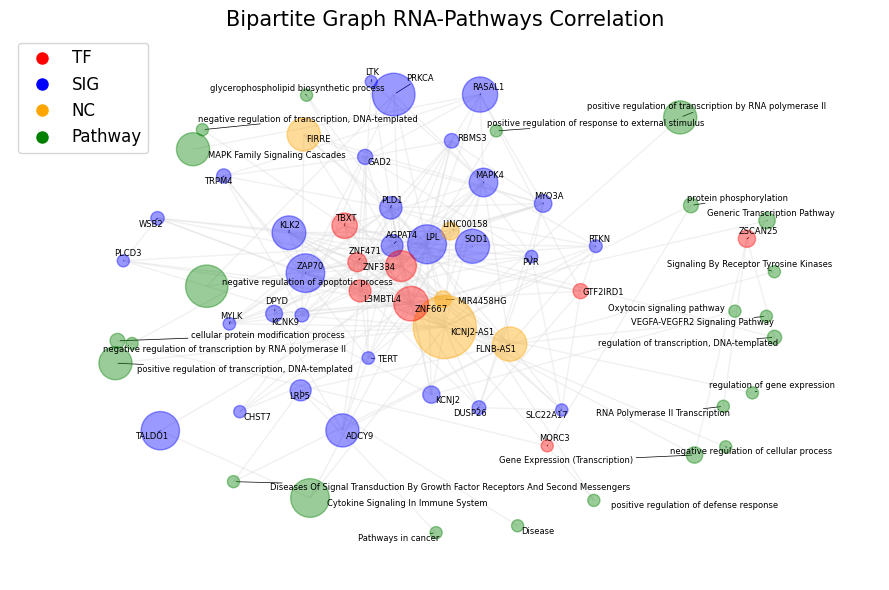

In [16]:
# Degree-centrality
# largest connected component
F = G
components = nx.connected_components(F)
largest_component = max(components, key=len)
F = F.subgraph(largest_component)

# compute centrality
centrality = nx.betweenness_centrality(F, k=10, endpoints=True)

# compute community structure
lpc = nx.community.label_propagation_communities(F)
community_index = {n: i for i, com in enumerate(lpc) for n in com}

# Function to clean node labels by removing specified patterns
def clean_label(label):
    # Patterns to be removed: R-HSA-XXXXX, WPXXXX, and (GO:XXXXXXX)
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# Assuming F is your graph
# Assuming community_index and centrality are already computed

# Create a dictionary of cleaned labels
cleaned_labels = {node: clean_label(node) for node in F.nodes()}

# Compute positions for the nodes using spring layout with an increased k parameter
pos = nx.spring_layout(F, k=1, seed=1350)  # Increased k to spread nodes further apart

# Define node colors based on the 'Type' attribute
type_color_map = {'TF': 'red', 'SIG': 'blue', 'NC': 'orange', 'Pathway': 'green'}
node_color = [type_color_map.get(F.nodes[node]['Type'], 'grey') for node in F.nodes()]

# Create the figure with adjusted size
fig, ax = plt.subplots(figsize=(9, 6))  # Increase figure size for more space

# Define node size based on centrality
node_size = [v * 5000 for v in centrality.values()]  # Reduce node size scaling

# Draw the network graph with the new node colors
nx.draw_networkx_nodes(
    F,
    pos=pos,
    node_color=node_color,
    node_size=node_size,
    alpha=0.4
)
nx.draw_networkx_edges(
    F,
    pos=pos,
    edge_color="gainsboro",
    alpha=0.4
)

# Collect text objects for adjust_text
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    text = ax.text(x, y, label, fontsize=6, ha='center', va='center')
    texts.append(text)

# Adjust text to minimize overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

# Add legend for node colors
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10)
           for color in type_color_map.values()]
labels = list(type_color_map.keys())
ax.legend(handles=handles, labels=labels, loc='upper left', fontsize=12)

# Adjust layout and remove axis
plt.title('Bipartite Graph RNA-Pathways Correlation', fontsize=15)
ax.margins(0.1, 0.05)
fig.tight_layout()
plt.axis("off")

# Save the figure as SVG
plt.savefig('../../figures/CLL_Bipartite_graph.png', format='jpeg', dpi=600)
plt.show()


# Load NetBID2 res BCMO

In [15]:
res_bcmo = pd.read_excel("../../results/BCMO/BCMO_NetBID2_ms_tab.xlsx")
res_bcmo = res_bcmo[['originalID', 'funcType', 'Size', 'logFC.U.Vs.M_DA', 'adj.P.Val.U.Vs.M_DA', 'Z.U.Vs.M_DA', 'logFC.U.Vs.M_DE', 'adj.P.Val.U.Vs.M_DE', 'Z.U.Vs.M_DE']]
res_bcmo.rename(columns={
    'originalID': 'ID',
    'funcType': 'Type',
    'logFC.U.Vs.M_DA': 'logFC_DA',
    'adj.P.Val.U.Vs.M_DA': 'adj.P.Val_DA',
    'Z.U.Vs.M_DA': 'Z-score_DA',
    'logFC.U.Vs.M_DE': 'logFC_DE',
    'adj.P.Val.U.Vs.M_DE': 'adj.P.Val_DE',
    'Z.U.Vs.M_DE': 'Z-score_DE',
}, inplace=True)

# Create a temporary column to give priority to "TF" rows
res_bcmo['priority'] = res_bcmo['Type'].apply(lambda x: 0 if x == 'TF' else 1)

# Sort the DataFrame by the 'priority' column (TF first) and by ID to make sure we keep the first occurrence
res_bcmo = res_bcmo.sort_values(by=['priority', 'ID'])

# Remove duplicated rows by 'ID', keeping the first occurrence (which should be the "TF" if it's present)
res_bcmo = res_bcmo.drop_duplicates(subset='ID', keep='first')

res_bcmo = res_bcmo.drop(columns=['priority'])

res_bcmo_filt_overt = res_bcmo[
    (res_bcmo['adj.P.Val_DA'] < 0.05) &
    (res_bcmo['adj.P.Val_DE'] < 0.05) &
    (res_bcmo['Size'] > 30)
]

res_bcmo_filt_hidden = res_bcmo[
    (res_bcmo['adj.P.Val_DA'] < 0.05) &
    (res_bcmo['adj.P.Val_DE'] > 0.05) &
    (res_bcmo['Size'] > 30)
]

print("Overt Drivers:", len(res_bcmo_filt_overt), "\n"
      "Hidden_Drivers:", len(res_bcmo_filt_hidden), "\n"
      "Overt TFs:", len(res_bcmo_filt_overt[res_bcmo_filt_overt['Type'] == "TF"]), "\n"
      "Overt SIGs:", len(res_bcmo_filt_overt[res_bcmo_filt_overt['Type'] == "SIG"]), "\n"
      "Overt NCs:", len(res_bcmo_filt_overt[res_bcmo_filt_overt['Type'] == "NC"]), "\n"
      "Hidden TFs:", len(res_bcmo_filt_hidden[res_bcmo_filt_hidden['Type'] == "TF"]), "\n"
      "Hidden SIGs:", len(res_bcmo_filt_hidden[res_bcmo_filt_hidden['Type'] == "SIG"]), "\n"
      "Hidden NCs:", len(res_bcmo_filt_hidden[res_bcmo_filt_hidden['Type'] == "NC"]))

Overt Drivers: 1176 
Hidden_Drivers: 2261 
Overt TFs: 161 
Overt SIGs: 652 
Overt NCs: 363 
Hidden TFs: 353 
Hidden SIGs: 1059 
Hidden NCs: 849


# BoxPlot for Expression of lncRNAs

## For BCMO

Unique IGHV values: ['U' 'M']


/tmp/ipython-input-29-3295669289.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IGHV', y='Expression', data=df_plot, order=['U', 'M'],
/tmp/ipython-input-29-3295669289.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IGHV', y='Expression', data=df_plot, order=['U', 'M'],
/tmp/ipython-input-29-3295669289.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IGHV', y='Expression', data=df_plot, order=['U', 'M'],


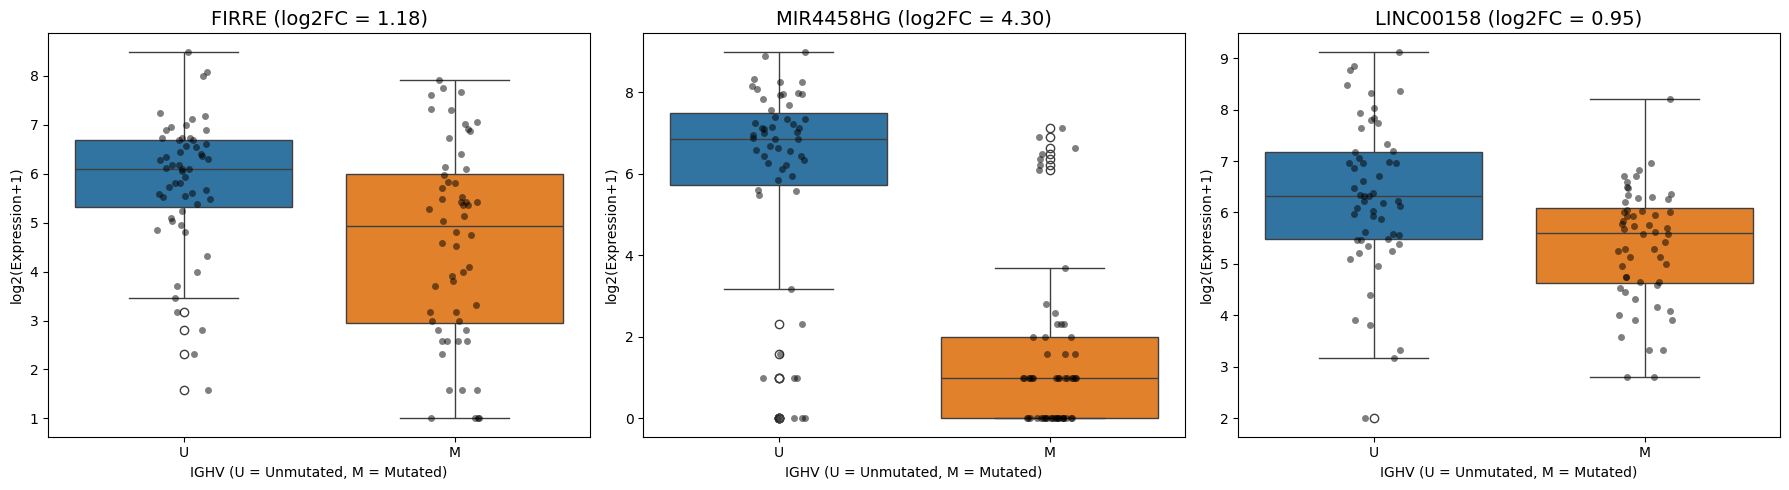

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# 1. Load files
# ------------------------------
count_matrix = pd.read_csv("Outputs/Tables/BCMO/count_matrix.csv", index_col=0)
metadata = pd.read_csv("Outputs/Tables/BCMO/metadata.csv")

# ------------------------------
# 2. Prepare metadata
# ------------------------------
metadata = metadata.set_index('Sample_ID')
metadata['IGHV'] = metadata['IGHV'].replace({
    'Unmutated': 'U',
    'Mutated': 'M'
})
print("Unique IGHV values:", metadata['IGHV'].unique())

# ------------------------------
# 3. Genes to plot + log2FC values
# ------------------------------
genes = ['FIRRE', 'MIR4458HG', 'LINC00158']
log2FCs = {'FIRRE': 1.18, 'MIR4458HG': 4.30, 'LINC00158': 0.95}

# ------------------------------
# 4. Setup figure for 1 row × 3 columns
# ------------------------------
palette = {'U': '#1f77b4', 'M': '#ff7f0e'}
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# ------------------------------
# 5. Loop through genes
# ------------------------------
for ax, gene_name in zip(axes, genes):
    if gene_name not in count_matrix.index:
        raise ValueError(f"{gene_name} not found in count matrix!")

    gene_expr = count_matrix.loc[gene_name]
    common_samples = gene_expr.index.intersection(metadata.index)
    gene_expr = gene_expr[common_samples]
    ighv = metadata.loc[common_samples, 'IGHV']

    # Log2 transform
    log_expr = np.log2(gene_expr + 1)

    df_plot = pd.DataFrame({
        'Sample': common_samples,
        'Expression': log_expr.values,
        'IGHV': ighv.values
    })

    sns.boxplot(x='IGHV', y='Expression', data=df_plot, order=['U', 'M'],
                palette=palette, ax=ax)
    sns.stripplot(x='IGHV', y='Expression', data=df_plot, color='black',
                  alpha=0.5, order=['U', 'M'], ax=ax)

    log2FC = log2FCs[gene_name]
    ax.set_title(f'{gene_name} (log2FC = {log2FC:.2f})', fontsize=14)
    ax.set_xlabel('IGHV (U = Unmutated, M = Mutated)')
    ax.set_ylabel('log2(Expression+1)')

# ------------------------------
# 6. Final adjustments & show
# ------------------------------
plt.tight_layout()
plt.show()


## For ICGC

Unique IGHV values: ['M' 'U']


/tmp/ipython-input-30-91321287.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IGHV', y='Expression', data=df_plot, order=['U', 'M'],
/tmp/ipython-input-30-91321287.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IGHV', y='Expression', data=df_plot, order=['U', 'M'],
/tmp/ipython-input-30-91321287.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IGHV', y='Expression', data=df_plot, order=['U', 'M'],


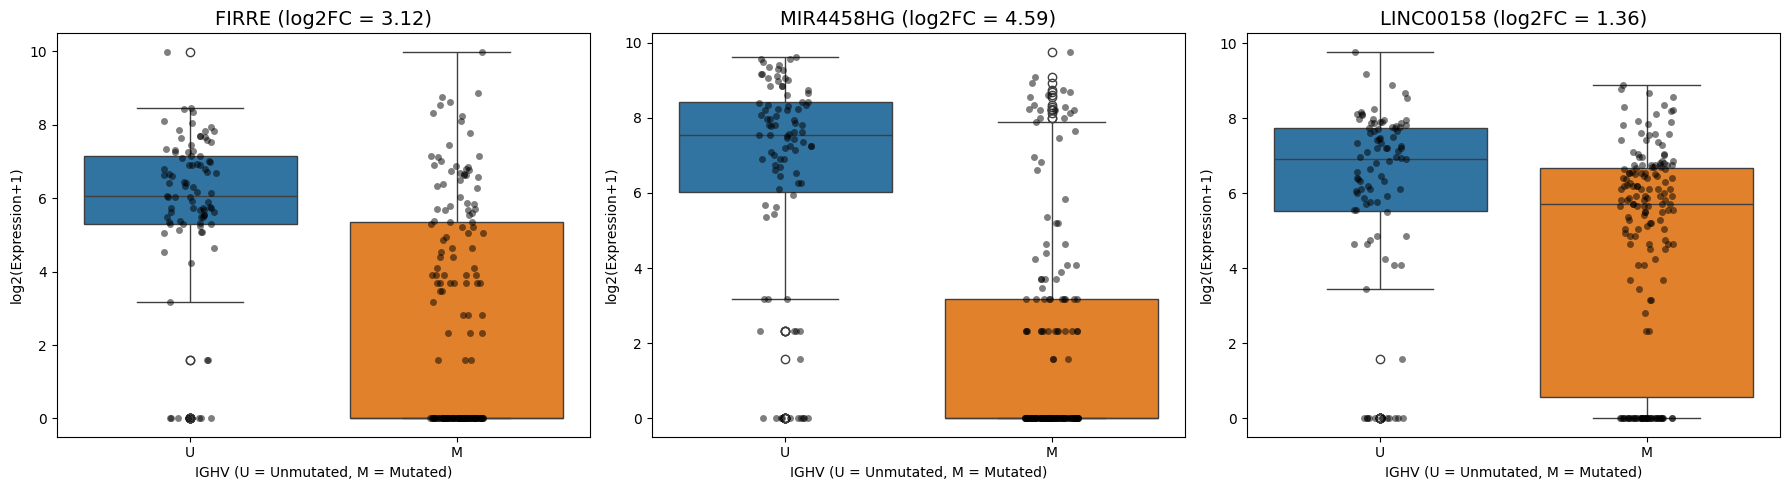

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------
# 1. Load files
# ------------------------------
count_matrix = pd.read_csv("Outputs/Tables/ICGC/count_matrix.csv", index_col=0)
metadata = pd.read_csv("Outputs/Tables/ICGC/metadata.csv")

# ------------------------------
# 2. Prepare metadata
# ------------------------------
metadata = metadata.set_index('Samples')
metadata['IGHV'] = metadata['IGHV'].replace({
    'Unmutated': 'U',
    'Mutated': 'M'
})
print("Unique IGHV values:", metadata['IGHV'].unique())

# ------------------------------
# 3. Genes to plot + log2FC values
# ------------------------------
genes = ['FIRRE', 'MIR4458HG', 'LINC00158']
log2FCs = {'FIRRE': 3.12, 'MIR4458HG': 4.59, 'LINC00158': 1.36}

# ------------------------------
# 4. Setup figure for 1 row × 3 columns
# ------------------------------
palette = {'U': '#1f77b4', 'M': '#ff7f0e'}
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# ------------------------------
# 5. Loop through genes
# ------------------------------
for ax, gene_name in zip(axes, genes):
    if gene_name not in count_matrix.index:
        raise ValueError(f"{gene_name} not found in count matrix!")

    gene_expr = count_matrix.loc[gene_name]
    common_samples = gene_expr.index.intersection(metadata.index)
    gene_expr = gene_expr[common_samples]
    ighv = metadata.loc[common_samples, 'IGHV']

    df_plot = pd.DataFrame({
        'Sample': common_samples,
        'Expression': gene_expr.values,  # raw counts
        'IGHV': ighv.values
    })

    sns.boxplot(x='IGHV', y='Expression', data=df_plot, order=['U', 'M'],
                palette=palette, ax=ax)
    sns.stripplot(x='IGHV', y='Expression', data=df_plot, color='black',
                  alpha=0.5, order=['U', 'M'], ax=ax)

    log2FC = log2FCs[gene_name]
    ax.set_title(f'{gene_name} (log2FC = {log2FC:.2f})', fontsize=14)
    ax.set_xlabel('IGHV (U = Unmutated, M = Mutated)')
    ax.set_ylabel('log2(Expression+1)')

# ------------------------------
# 6. Final adjustments & show
# ------------------------------
plt.tight_layout()
plt.show()


Unique IGHV values: ['M' 'U']


/tmp/ipython-input-31-510749577.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IGHV', y='Expression', data=df_plot, order=['U', 'M'],
/tmp/ipython-input-31-510749577.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IGHV', y='Expression', data=df_plot, order=['U', 'M'],
/tmp/ipython-input-31-510749577.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IGHV', y='Expression', data=df_plot, order=['U', 'M'],
/tmp/ipython-input-31-510749577.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

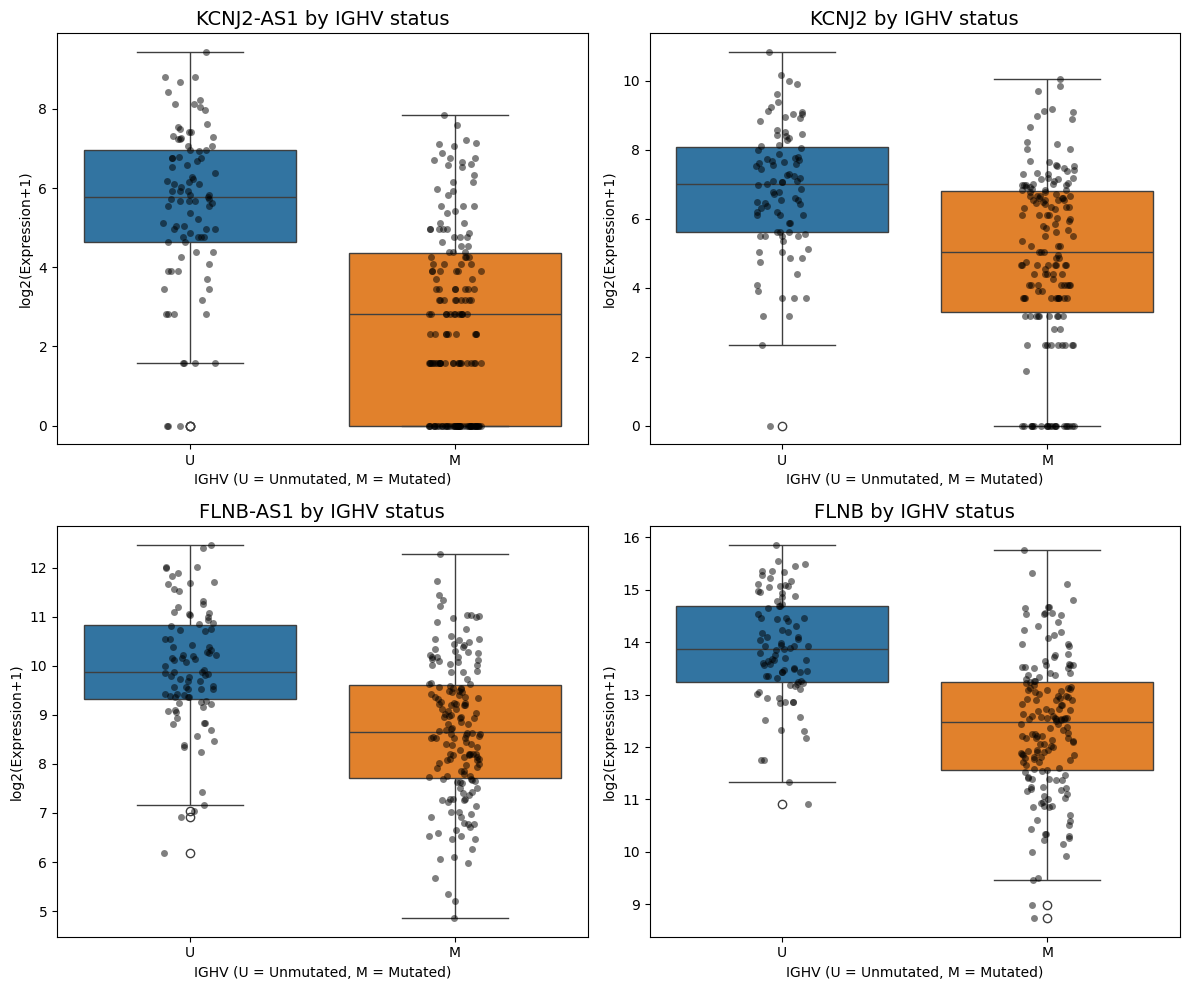

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# 1. Load files
# ------------------------------
count_matrix = pd.read_csv("Outputs/Tables/ICGC/count_matrix.csv", index_col=0)
metadata = pd.read_csv("Outputs/Tables/ICGC/metadata.csv")

# ------------------------------
# 2. Prepare metadata
# ------------------------------
metadata = metadata.set_index('Samples')
metadata['IGHV'] = metadata['IGHV'].replace({
    'Unmutated': 'U',
    'Mutated': 'M'
})
print("Unique IGHV values:", metadata['IGHV'].unique())

# ------------------------------
# 3. Genes to plot
# ------------------------------
genes = ['KCNJ2-AS1', 'KCNJ2', 'FLNB-AS1', 'FLNB']

# ------------------------------
# 4. Setup figure for 2 rows × 2 columns
# ------------------------------
palette = {'U': '#1f77b4', 'M': '#ff7f0e'}
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()  # flatten to 1D list for easy looping

# ------------------------------
# 5. Loop through genes
# ------------------------------
for ax, gene_name in zip(axes, genes):
    if gene_name not in count_matrix.index:
        raise ValueError(f"{gene_name} not found in count matrix!")

    gene_expr = count_matrix.loc[gene_name]
    common_samples = gene_expr.index.intersection(metadata.index)
    gene_expr = gene_expr[common_samples]
    ighv = metadata.loc[common_samples, 'IGHV']

    df_plot = pd.DataFrame({
        'Sample': common_samples,
        'Expression': gene_expr.values,  # raw counts
        'IGHV': ighv.values
    })

    sns.boxplot(x='IGHV', y='Expression', data=df_plot, order=['U', 'M'],
                palette=palette, ax=ax)
    sns.stripplot(x='IGHV', y='Expression', data=df_plot, color='black',
                  alpha=0.5, order=['U', 'M'], ax=ax)

    ax.set_title(f'{gene_name} by IGHV status', fontsize=14)
    ax.set_xlabel('IGHV (U = Unmutated, M = Mutated)')
    ax.set_ylabel('log2(Expression+1)')  # <-- Raw counts

# ------------------------------
# 6. Final adjustments & show
# ------------------------------
plt.tight_layout()
plt.show()
